In [64]:
from pca_core import load_data, PCAModel, GPSurrogates, load_with_gp_smooth, CENTRE_FREQS, axes_crossing, calculate_oaspl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re
import matplotlib.cm as cm
import scienceplots
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import joblib
import librosa
from scipy.signal import welch, medfilt
from sklearn.metrics import mean_squared_error
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import scipy.stats as stats
from matplotlib.lines import Line2D

In [19]:
plt.style.use('science')
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['mathtext.fontset'] = 'cm'  # looks identical to LaTeX
matplotlib.rcParams['font.size'] = 20        # default for everything
matplotlib.rcParams['axes.labelsize'] = 22   # axis labels
matplotlib.rcParams['legend.fontsize'] = 20  # legend
matplotlib.rcParams['xtick.labelsize'] = 16  # tick labels
matplotlib.rcParams['ytick.labelsize'] = 16

# axes.labelsize : 20
# xtick.labelsize : 16
# ytick.labelsize : 16
# lines.markersize: 10
# lines.linewidth: 2

n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

In [22]:
centre_freqs = CENTRE_FREQS
PSI_PCA_OUTLIER  = joblib.load("../GPS_PKL/pca_pressure.pkl")
ETA_PCA_OUTLIER = joblib.load("../GPS_PKL/pca_efficiency.pkl")
AUDIO_PCA_OUTLIERED = joblib.load("../GPS_PKL/pca_noise.pkl")
GP_PSI   = joblib.load("../GPS_PKL/gp_pressure.pkl")
GP_ETA = joblib.load("../GPS_PKL/gp_efficiency.pkl")
GP_AUDIO      = joblib.load("../GPS_PKL/gp_noise.pkl")


In [11]:
runs, r2s_psi, r2s_eta = load_data(base_dir="..")

Loading runs: 100%|██████████| 85/85 [00:14<00:00,  5.78it/s]

[AVG R2]: psi=0.9719147270038881, eta=0.9923270924826199
[STD R2]: psi=0.0211089287299016, eta=0.010228949463323408
[MIN R2]: psi=0.8887480062210076, eta=0.9075314055979926


In [12]:
PHI_COMMON = np.linspace(0.05, 0.25, 100)
def get_psi_eta_gp_with_end(index):
    return runs[index]['psi'], runs[index]["phi_end"], runs[index]['eta']

In [13]:
# Find matching STL stem
def broadband_from_index(index, remove_peaks = True):
    base_dir = ".."

    stl_file = None
    stl_dir  = os.path.join(base_dir, "stl_files")
    for f in os.listdir(stl_dir):
        if re.search(rf"DOE_{index}", f) and f.endswith(".stl"):
            stl_file = f[:-4]   # strip .stl
    if stl_file is None:
        raise ValueError(f"No STL file found for run {index}")
    # ── Audio  (kept for future audio tab) ──────────────────────────

    audio_path = os.path.join(base_dir, "audio", "doe_data_2", f"{stl_file}.wav")
    audio_data, sample_rate = None, None
    if os.path.exists(audio_path):
        try:
            audio_data, sample_rate = librosa.load(audio_path, sr=None)
        except Exception as e:
            print(f"  [audio] {stl_file}: {e}")
            
    nperseg = len(audio_data)//8
    noverlap = nperseg//2

    ## Plot ##
    frequencies, power = welch(
        audio_data,
        fs=sample_rate,
        window='blackman',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling = 'spectrum'
        )

    amplitude = np.sqrt(power)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)
    if remove_peaks:
        amplitude_db_peaks = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
        return frequencies, amplitude_db_peaks
    else:
        return frequencies, amplitude_db

# IEC 61260 standard 1/6 octave centre frequencies
# Reference frequency is 1000 Hz, bands indexed from there
def get_sixth_octave_centres(f_min=20, f_max=20000):
    centres = []
    # 1/6 octave: fc = 1000 * 2^(n/6)
    n = -30  # start well below f_min
    while True:
        fc = 1000 * 2**(n/6)
        if fc > f_max:
            break
        if fc >= f_min:
            centres.append(fc)
        n += 1
    return np.array(centres)

centre_freqs = get_sixth_octave_centres(f_min=20, f_max=20000)

def a_weight(frequencies):
    """Compute A-weighting correction (dB) at arbitrary frequencies using the analytic formula."""
    f = np.asarray(frequencies, dtype=float)
    f2 = f**2
    
    numerator   = 12194**2 * f2**2
    denominator = ((f2 + 20.6**2) * 
                   np.sqrt((f2 + 107.7**2) * (f2 + 737.9**2)) * 
                   (f2 + 12194**2))
    
    RA = numerator / denominator
    a_db = 20 * np.log10(RA) + 2.00  # +2.00 normalises to 0dB at 1kHz
    return a_db


def sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db):
    """Compute 1/6 octave band levels from a narrow-band spectrum."""    
    
    centre_freqs = get_sixth_octave_centres(f_min=20, f_max=20000)
    
    a_weighting_db = a_weight(centre_freqs)
    
    # 1/6 octave band edges:
    lower_edges = centre_freqs * 2**(-1/12)
    upper_edges = centre_freqs * 2**(+1/12)
    
    # Convert amplitude from dB to linear power
    power_linear = 10 ** (amplitude_db / 10)
    
    band_levels = []
    for i, (f_low, f_high) in enumerate(zip(lower_edges, upper_edges)):
        mask = (frequencies >= f_low) & (frequencies < f_high)
        if mask.any():
            band_power = power_linear[mask].sum()
            band_levels.append(10 * np.log10(band_power) + a_weighting_db[i])
        else:
            band_levels.append(np.nan)  # no bins in this band
    
    return centre_freqs, np.array(band_levels)
def sixth_octave_bands_from_index(index):
    frequencies, amplitude_db_peaks = broadband_from_index(index, remove_peaks=True)
    # amplitude_a_weighted =  a_weight_sixth_octave(frequencies, amplitude_db_peaks)
    return sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db_peaks)

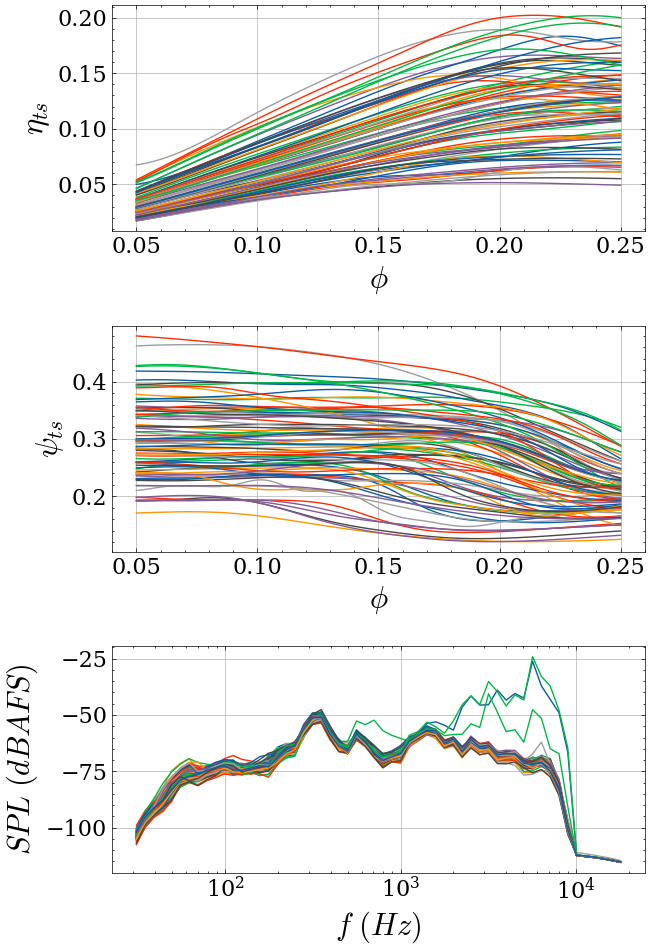

In [20]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
# index = 79
for index in range(85):
    psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)

    # ETA

    ax[0].plot(PHI_COMMON, eta, label=f"run:{index}")
    ax[0].grid()
    ax[0].set_xlabel('$\phi$')
    ax[0].set_ylabel('$\eta_{ts}$')
    ax[0].set_xlim(0.04, 0.26)

    # PSI

    ax[1].plot(PHI_COMMON, psi,)

    ax[1].grid()
    ax[1].set_xlabel('$\phi$')
    ax[1].set_ylabel('$\psi_{ts}$')
    ax[1].set_xlim(0.04, 0.26)

    # Audio

    centre_freqs, band_levels = sixth_octave_bands_from_index(index)

    ax[2].semilogx(centre_freqs, band_levels)    
    # ax[2].set_xlim(100, 500)
    ax[2].grid()
    ax[2].set_xlabel('$f \ (Hz)$')
    ax[2].set_ylabel('$SPL \ (dBAFS)$')


# fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\final_presentation_diagrams\all_data.svg', bbox_inches='tight')
plt.show()

In [23]:
def return_real_index_from_fan(pca, fan_index):
    try:
        idx = np.where(pca.fan_indices == fan_index)[0][0]
    except IndexError as e:
        print("[Index Error] Fan index has been outliered, try again. ", e)
        return None
    return idx

In [26]:
file_names = sorted(os.listdir(r"..\data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group()))
def get_psi_eta_phi_real(index, return_confidence=False):
    file = file_names[index]
    data_path = r"..\data\doe_data\\"+file
    df = pd.read_csv(data_path)
    psi_real = df['pressure_rise_coefficient_mean']
    eta_real = df['efficiency_mean']
    phi_real = df['flow_coefficient_mean']
    phi_confidence = 1.96 * df['flow_coefficient_stddev'] / np.sqrt(100)
    psi_confidence = 1.96 * df['pressure_rise_coefficient_stddev'] / np.sqrt(100)
    if return_confidence:
        return psi_real,eta_real, phi_real, phi_confidence, psi_confidence
    else:
        return psi_real,eta_real, phi_real

In [27]:
fan_index = 79
list_index_psi = return_real_index_from_fan(PSI_PCA_OUTLIER, fan_index)
list_index_eta = return_real_index_from_fan(ETA_PCA_OUTLIER, fan_index)
list_index_audio = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, fan_index)
m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = GP_PSI.predict(PSI_PCA_OUTLIER.params[list_index_psi])
m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = GP_ETA.predict(ETA_PCA_OUTLIER.params[list_index_eta])
m_audio, s_audio = GP_AUDIO.predict(AUDIO_PCA_OUTLIERED.params[list_index_audio])

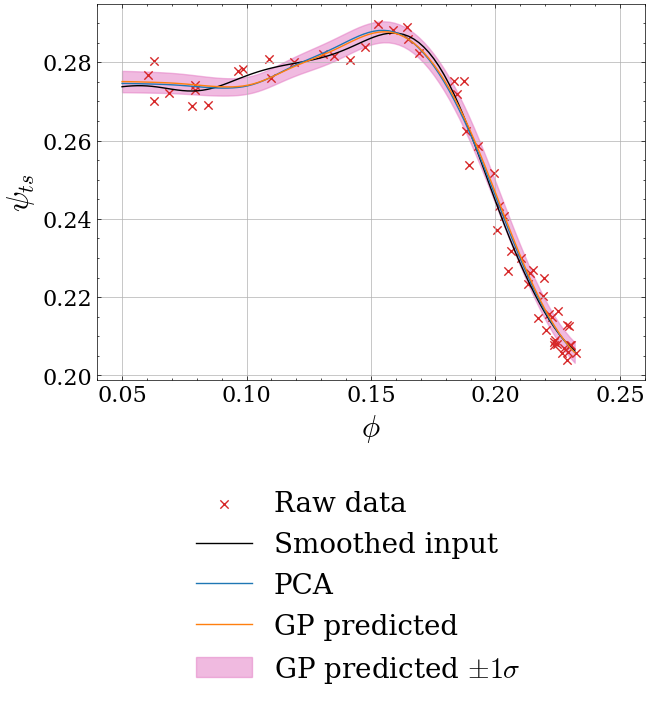

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 5), sharex=False)

psi, phi_end, eta = get_psi_eta_gp_with_end(index=fan_index)
psi_real,eta_real, phi_real = get_psi_eta_phi_real(index=fan_index)

# ETA
# smoothed_mask = PHI_COMMON < phi_end
# mask = ETA_PCA_OUTLIER.return_mask(s_m_eta, e_m_eta)
# scores_eta = ETA_PCA_OUTLIER.scores[list_index_eta]
# modes_eta  = ETA_PCA_OUTLIER.modes[:,mask]
# mean_curve_eta = ETA_PCA_OUTLIER.mean_curve[mask]

# var       = sum((ETA_PCA_OUTLIER.modes[k] * s_eta[k]) ** 2 for k in range(ETA_PCA_OUTLIER.n_modes))
# std       = np.sqrt(var)[mask]

# ax[0].scatter(phi_real, eta_real, color=colours[3], marker='x', label='Raw data')
# ax[0].plot(PHI_COMMON[smoothed_mask], eta[smoothed_mask], color='k', label='Smoothed input')
# ax[0].plot(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(scores_eta)[mask], color=colours[0], label=f'PCA')
# ax[0].plot(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(m_eta)[mask], color=colours[1], label=f'GP predicted')
# ax[0].fill_between(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(m_eta)[mask]-std, ETA_PCA_OUTLIER.reconstruct(m_eta)[mask]+std, color=colours[6], label=f'GP predicted $\pm1\sigma$', alpha=0.5, zorder=0)
# ax[0].grid()
# ax[0].set_xlabel('$\phi$')
# ax[0].set_ylabel('$\eta$')
# ax[0].set_xlim(0.04, 0.26)

# PSI
smoothed_mask = PHI_COMMON < phi_end
mask = PSI_PCA_OUTLIER.return_mask(s_m_psi, e_m_psi)
scores_psi = PSI_PCA_OUTLIER.scores[list_index_psi]
modes_psi  = PSI_PCA_OUTLIER.modes[:,mask]
mean_curve_psi = PSI_PCA_OUTLIER.mean_curve[mask]

var       = sum((PSI_PCA_OUTLIER.modes[k] * s_psi[k]) ** 2 for k in range(PSI_PCA_OUTLIER.n_modes))
std       = np.sqrt(var)[mask]

ax.scatter(phi_real, psi_real, color=colours[3], marker='x', label='Raw data')
ax.plot(PHI_COMMON[smoothed_mask], psi[smoothed_mask], color='k', label='Smoothed input')
ax.plot(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(scores_psi)[mask], color=colours[0], label='PCA')
ax.plot(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(m_psi)[mask], color=colours[1], label='GP predicted')
ax.fill_between(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(m_psi)[mask]-std, PSI_PCA_OUTLIER.reconstruct(m_psi)[mask]+std, color=colours[6], alpha=0.5, zorder=0, label='GP predicted $\pm1\sigma$')
ax.grid()
ax.set_xlabel('$\phi$')
ax.set_ylabel('$\psi_{ts}$')
ax.set_xlim(0.04, 0.26)

# SPL
# scores_audio = AUDIO_PCA_OUTLIERED.scores[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, index)]
# modes_audio  = AUDIO_PCA_OUTLIERED.modes
# mean_curve_audio = AUDIO_PCA_OUTLIERED.mean_curve

# var       = sum((AUDIO_PCA_OUTLIERED.modes[k] * s_audio[k]) ** 2 for k in range(AUDIO_PCA_OUTLIERED.n_modes))
# std       = np.sqrt(var)

# centre_freqs, band_levels = sixth_octave_bands_from_index(index)

# ax[2].semilogx(centre_freqs, band_levels, color='k')
# ax[2].semilogx(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(scores_audio), color=colours[0])
# ax[2].semilogx(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(m_audio), color=colours[1])
# ax[2].fill_between(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(m_audio)-std, AUDIO_PCA_OUTLIERED.reconstruct(m_audio)+std, color=colours[6], alpha=0.5, zorder=0)
# ax[2].grid()
# ax[2].set_xlabel('$f \ (Hz)$')
# ax[2].set_ylabel('$SPL \ (dBAFS)$')


fig.legend(bbox_to_anchor=(0.3, -0.01), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\final_presentation_diagrams\gp_comparison.svg', bbox_inches='tight')
plt.show()

84
82
82


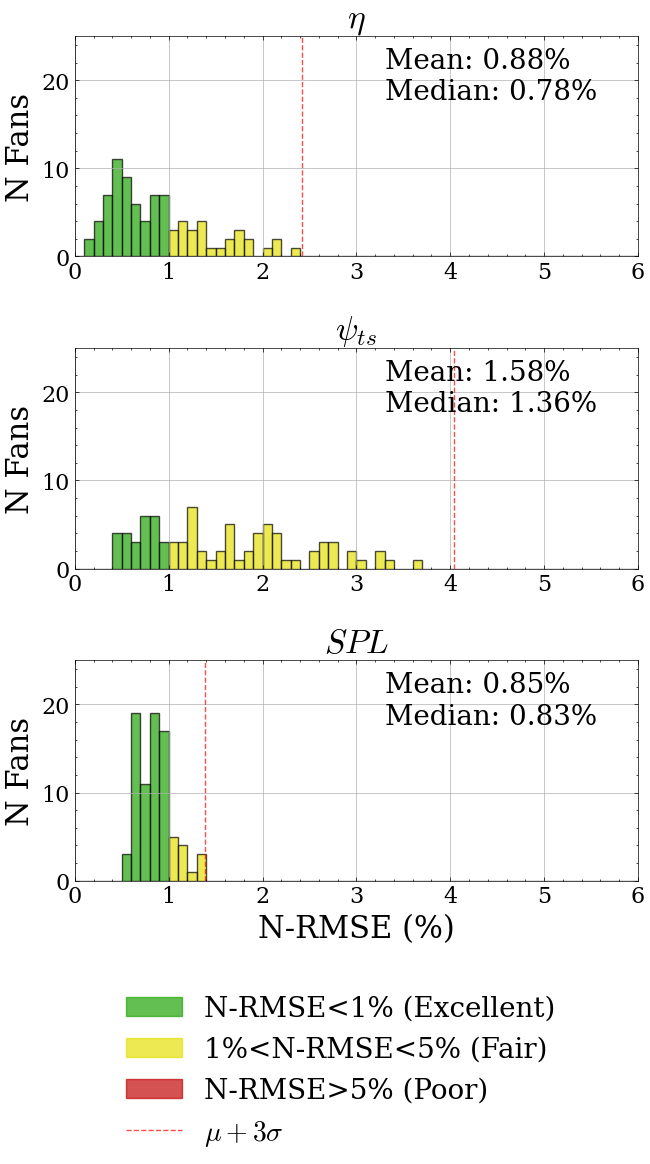

In [45]:
def get_nrmse_and_stats_with_gp(pca, gp, audio=False):
    X = np.vstack([r[pca.curve_key] for r in pca.runs])
    X_reconstructed = []
    print(len(pca.params))
    for p in pca.params:
        if audio:
            m, _ = gp.predict(p)
        else:
            m, _,_,_,_,_ = gp.predict(p)
        X_reconstructed.append(pca.reconstruct(m))
    mins = np.array([np.min(x) for x in X])
    maxs = np.array([np.max(x) for x in X])
    maxs_mins = maxs-mins
    # print(max(maxs_mins))
    
    rmse_per_run = np.array([
        np.sqrt(mean_squared_error(X[i], X_reconstructed[i]))/(maxs[i]-mins[i]) for i in range(len(pca.runs))
    ])*100
    
    return rmse_per_run, np.mean(rmse_per_run), np.median(rmse_per_run)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)

bin_width = 0.1
bins = np.arange(0, 6 + bin_width, bin_width)
excellent_val = 1
fair_val = 5
n_stds = 3

# ETA
rmse_per_run_eta, mean_rmse_eta, median_rmse_eta = get_nrmse_and_stats_with_gp(ETA_PCA_OUTLIER, GP_ETA)
n, bins, patches = ax[0].hist(rmse_per_run_eta, bins=bins, density = False, edgecolor='black')
ax[0].axvline(mean_rmse_eta+n_stds*np.std(rmse_per_run_eta), color='red', alpha=0.7, linestyle='--')
ax[0].grid()
ax[0].set_ylabel('N Fans')
ax[0].set_title("$\eta$")
ax[0].set_xlim(0,6)
ax[0].set_ylim(0,25)
ax[0].text(0.55, 0.95, f'Mean: {mean_rmse_eta:.2f}% \nMedian: {median_rmse_eta:.2f}%',
        transform=ax[0].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# PSI
rmse_per_run_psi, mean_rmse_psi, median_rmse_psi = get_nrmse_and_stats_with_gp(PSI_PCA_OUTLIER, GP_PSI)

n, bins, patches = ax[1].hist(rmse_per_run_psi, bins=bins, density = False, edgecolor='black')
ax[1].axvline(mean_rmse_psi+n_stds*np.std(rmse_per_run_psi), color='red', alpha=0.7, linestyle='--')
ax[1].grid()
ax[1].set_ylabel('N Fans')
ax[1].set_title("$\psi_{ts}$")
ax[1].set_xlim(0,6)
ax[1].set_ylim(0,25)
ax[1].text(0.55, 0.95, f'Mean: {mean_rmse_psi:.2f}% \nMedian: {median_rmse_psi:.2f}%',
        transform=ax[1].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# SPL     
rmse_per_run, mean_rmse, median_rmse = get_nrmse_and_stats_with_gp(AUDIO_PCA_OUTLIERED, GP_AUDIO, audio=True)
n, bins, patches = ax[2].hist(rmse_per_run, bins=bins, density = False, edgecolor='black')
ax[2].axvline(mean_rmse+n_stds*np.std(rmse_per_run), color='red', alpha=0.7, linestyle='--')
ax[2].grid()
ax[2].set_ylabel('N Fans')
ax[2].set_xlabel('N-RMSE (%)')
ax[2].set_xlim(0,6)
ax[2].set_ylim(0,25)
ax[2].set_title("$SPL$")
ax[2].text(0.55, 0.95, f'Mean: {mean_rmse:.2f}% \nMedian: {median_rmse:.2f}%',
        transform=ax[2].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# Legend
green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label=f'N-RMSE<{excellent_val}% (Excellent)')
yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label=f'{excellent_val}%<N-RMSE<{fair_val}% (Fair)')
red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label=f'N-RMSE>{fair_val}% (Poor)')
threshold_line = mlines.Line2D([], [], color='red', alpha=0.7, linestyle='--', label=f'$\mu+{n_stds}\sigma$')


fig.legend(handles=[green_patch, yellow_patch, red_patch, threshold_line], bbox_to_anchor=(0.2,-0.01), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\final_presentation_diagrams\gp_RMSE.svg', bbox_inches='tight')
plt.show()

In [46]:
def get_curve_from_params(pca, gp, params):
    if pca.curve_key == "audio_amplitude":
        pred, std = gp.predict(params)
        return CENTRE_FREQS, pca.reconstruct(pred)
    else:
        pred, std, _, _, phi_end, _ = gp.predict(params)
        mask = PHI_COMMON < phi_end
        curve = pca.reconstruct(pred)[mask]
        return PHI_COMMON[mask], curve, mask

In [53]:
def contour_plot_vals_from_params(params):
    phi_max_vals = []
    psi_max_vals = []
    eta_max_vals = []
    oaspl_vals = []

    with tqdm(total=len(params), desc="Loading runs") as pbar:
        for i, param in enumerate(params):
            # Call GPs to get curves
            phi_vals, p_curve, _ = get_curve_from_params(PSI_PCA_OUTLIER, GP_PSI, param)
            _, e_curve, _ = get_curve_from_params(ETA_PCA_OUTLIER, GP_ETA, param)
            _, n_curve = get_curve_from_params(AUDIO_PCA_OUTLIERED, GP_AUDIO, param)

            # Evaluate curves to get desired params
            phi_max = axes_crossing(phi_vals, p_curve)[1]
            # print(phi_max)
            psi_max = np.max(p_curve)
            eta_max = np.max(e_curve)
            oaspl = calculate_oaspl(n_curve)
            # print(oaspl)
            
            # Append to lists for plotting
            phi_max_vals.append(phi_max)
            psi_max_vals.append(psi_max)
            eta_max_vals.append(eta_max)
            oaspl_vals.append(oaspl)
            pbar.update(1)
            
    return np.array(phi_max_vals), np.array(psi_max_vals), np.array(eta_max_vals), np.array(oaspl_vals)

def blade_shapes():
    # Take params from csv
    file = '../doe_params.csv'
    data = pd.read_csv(file, index_col=None)
    # data = data.iloc[-5:]
    # print(data.head())
    # stopping = input("press enter to continue")
    xs=[]
    ys=[]
    filenames = os.listdir("..\\throughflow_output")
    for i, row in data.iterrows():
        if i != 59 and i!=61 and i!=35 and i!=56:
            continue
        # rows: ['mdot', 'DH_mid', 'incidence', 'Vexp', 'lean_compound', 'lean_straight', 'tip_clearance', 'n_blade']
        ### input params
        index = i
        n_blades = row['n_blade']
        rhub=0.015             # 15 mm hub radius
        rcase=0.040             # 40 mm case radius
        tip_clearance_percent = row['tip_clearance']
        tip_clearance_abs = tip_clearance_percent/100*rcase
        rtip = rcase-tip_clearance_abs
        RPM=3000.0             # 3000 rpm
        mdot=row['mdot']              # 0.05 kg/s (further reduced for better blade effect)
        DHmid=row['DH_mid']              # De Haller number = 0.9 (diffusion)
        INC=row['incidence']                # 2° incidence
        Vexp=row['Vexp']               # Vortex exponent 
        lean_max = row['lean_compound']        # Angle (degrees) of max lean
        lean_weighting = 1   # Form of lean curve (r*(1-r))**lean_weighting
        lean_straight = row['lean_straight'] # Straight lean angle (degrees)
        # filename = f"DOE_{index}_{n_blades}_{mdot:.4f}_{DHmid:.4f}_{INC:.2f}_{Vexp:.4f}_{lean_max:.4f}_{lean_weighting}_{lean_straight:.2f}_{tip_clearance_percent:.3f}"
        for f in filenames:
                if re.search(rf"DOE_{index}", f) and f.endswith("blade_sections.npz"):
                    filename = f
                    # stl_file = f[:-4]   # strip .stl
        # filename = f"DOE_{index}_{n_blades}_{mdot}_{DHmid}_{INC}_{Vexp}_{lean_max}_{lean_weighting}_{lean_straight}_{tip_clearance_percent}"
        # print(filename)
        # print(os.getcwd())
        os.chdir('../throughflow_output')
        # print(os.getcwd)
        output_filename =  filename#+"_blade_sections.npz"'../throughflow_output/'
        section_data = np.load(output_filename, allow_pickle=True)['sections'].item()['R1']
        from fan_generator_from_params import convert_to_cartesian,smooth_trailing_edges,convert_to_cylindrical
    
        XYZ_sections = []
        # Convert all section data to cartesian coordinates for stl generation
        for i, section in enumerate(section_data):
            X_cart, Y_cart, Z_cart = convert_to_cartesian(section)
            XYZ_sections.append(np.stack([X_cart, Y_cart, Z_cart], axis=1))

        # Make trailing edges
        XYZ_sections_complete = smooth_trailing_edges(XYZ_sections)
        
        midspan_index = len(section_data)-1
        midspan_shape = XYZ_sections_complete[midspan_index]
        # # print(midspan_shape, np.shape(midspan_shape))
        
        def xyz_to_cylindrical(vectors):
            """
            Convert a list of Cartesian (x, y, z) vectors to cylindrical (r, theta, z) coordinates.
            
            Parameters:
                vectors : array-like, shape (N, 3) - list of [x, y, z] vectors
            
            Returns:
                numpy array, shape (N, 3) - array of [r, theta, z] vectors
                where r is radial distance, theta is in radians, z is axial
            """
            vectors = np.array(vectors)
            
            x = vectors[:, 0]
            y = vectors[:, 1]
            z = vectors[:, 2]
            
            r     = np.sqrt(x**2 + y**2)
            theta = np.arctan2(y, x)   # returns values in [-pi, pi]
            
            return r, theta, z
        
        r,theta,z = xyz_to_cylindrical(midspan_shape)
        x = z#section_data[midspan_index]['x']
        y = r*theta#section_data[midspan_index]['theta']#np.multiply(section_data[midspan_index]['r'],)
        
        # print(mdot, DHmid)
        xs.append(x)
        ys.append(y)
        # import matplotlib.pyplot as plt
        # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # fig, ax = plt.subplots()
        # ax.plot(z,np.multiply(r,theta))
        
        # inset = inset_axes(ax, width="30%", height="30%", loc="upper right")
        # inset.plot(z,np.multiply(r,theta), color="coral")
        # inset.axis("off")
        
        # ax.grid()
        # plt.show()
        # print(mdot,DHmid)
    return xs,ys

def contour_plot_2x2(x, y, params, xlabel, ylabel, x_filename, y_filename):
    # Find the unique x and y values to get grid dimensions
    nx = len(np.unique(x))
    ny = len(np.unique(y))
    # Reshape into 2D grids
    X = x.reshape(ny, nx)
    Y = y.reshape(ny, nx)
    
    # v_min_psi = 0.10
    # v_max_psi = 0.50
    # psi_levels = np.linspace(v_min_psi, v_max_psi, int((v_max_psi-v_min_psi)/0.05)+1)
    # v_min_eta = 0.03
    # v_max_eta = 0.2
    # eta_levels = np.linspace(v_min_eta, v_max_eta, int((v_max_eta-v_min_eta)/0.01)+1)
    # v_min_phi = 0.15
    # v_max_phi = 0.95
    # phi_levels = np.linspace(v_min_phi, v_max_phi, int((v_max_phi-v_min_phi)/0.05)+2)
    # print(phi_levels)
    # v_min_oaspl = -47.5
    # v_max_oaspl = -41
    # oaspl_levels = np.linspace(v_min_oaspl, v_max_oaspl, int((v_max_oaspl-v_min_oaspl)/0.5)+1)

    def quadruple_levels(levels):
        new_levels = []
        for i in range(len(levels)-1):
            new_levels.append(levels[i])
            new_levels.append(levels[i]+(levels[i+1]-levels[i])/4)
            new_levels.append(levels[i]+(levels[i+1]-levels[i])/2)
            new_levels.append(levels[i]+3*(levels[i+1]-levels[i])/4)
        new_levels.append(levels[-1])
        return np.array(new_levels)
    
    
    # print(phi_levels)
    
    phi_max_vals, psi_max_vals, eta_max_vals, oaspl_vals = contour_plot_vals_from_params(params)
    # print(oaspl_vals[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)])
    
    smoothing_blades = (0,0)
    
    fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
    
    # from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    # if x_filename=="m_dot":
    #     xs,ys = blade_shapes()
    #     def insert_blade(loc,idx):
    #         inset = inset_axes(ax[0,0], width="30%", height="30%", loc=loc)
    #         inset.plot(xs[idx],ys[idx], color="coral")
    #         inset.axis("off")
    #     insert_blade("upper left",2)
    #     insert_blade("lower left",3)
    #     insert_blade("upper right",0)
    #     insert_blade("lower right",1)
    

    # Max psi contour plot
    z = np.array(psi_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[0, 0].contourf(X, Y, Z, levels=quadruple_levels(psi_levels), cmap='viridis', vmin=v_min_psi, vmax=v_max_psi)  # filled contours
    # cs = ax[0, 0].contour(X, Y, Z, levels=psi_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[0, 0].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[0, 0].contour(X, Y, Z, levels=cp.levels[::2], colors='black', linewidths=0.5)  # contour lines
    ax[0, 0].clabel(cs, inline=True, fontsize=8)  # label the lines
    ax[0, 0].set_ylabel(ylabel)
    ax[0,0].set_title(r'$\psi_{ts, max}$')
    if y_filename == "blade_count":
        ax[0, 0].set_yticks([5,6,7,8,9])

    # Max phi contour plot
    z = np.array(phi_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma=1.0)
    # cp = ax[1, 0].contourf(X, Y, Z, levels=quadruple_levels(phi_levels), cmap='viridis', vmin=v_min_phi, vmax=v_max_phi)  # filled contours
    # cs = ax[1, 0].contour(X, Y, Z, levels=phi_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[1, 0].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[1, 0].contour(X, Y, Z, levels=cp.levels[::2],colors='black', linewidths=0.5)  # contour lines
    ax[1, 0].clabel(cs, inline=True, fontsize=8)  # label the lines
    ax[1, 0].set_xlabel(xlabel)
    ax[1, 0].set_ylabel(ylabel)
    ax[1, 0].set_title(r'$\phi_{max}$')
    if y_filename == "blade_count":
        ax[1, 0].set_yticks([5,6,7,8,9])

    # Max eta contour plot
    z = np.array(eta_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[0, 1].contourf(X, Y, Z, levels=quadruple_levels(eta_levels), cmap='viridis', vmin=v_min_eta, vmax=v_max_eta)  # filled contours
    # cs = ax[0, 1].contour(X, Y, Z, levels=eta_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[0, 1].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[0, 1].contour(X, Y, Z,levels=cp.levels[::2], colors='black', linewidths=0.5)  # contour lines
    ax[0, 1].clabel(cs, inline=True, fontsize=8)
    ax[0, 1].set_title(r'$\eta_{max}$')
    if y_filename == "blade_count":
        ax[0, 1].set_yticks([5,6,7,8,9])

    # Max OASPL contour plot
    z = np.array(oaspl_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[1, 1].contourf(X, Y, Z, levels=quadruple_levels(oaspl_levels), cmap='viridis_r', vmin=v_min_oaspl, vmax=v_max_oaspl)  # filled contours
    # cs = ax[1, 1].contour(X, Y, Z, levels=oaspl_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[1, 1].contourf(X, Y, Z,levels=20, cmap='viridis')  # filled contours
    cs = ax[1, 1].contour(X, Y, Z, levels=cp.levels[::2],colors='black', linewidths=0.5)  # contour lines
    ax[1, 1].clabel(cs, inline=True, fontsize=8)
    ax[1, 1].set_xlabel(xlabel)
    ax[1, 1].set_title('$OASPL$')
    if y_filename == "blade_count":
        ax[1, 1].set_yticks([5,6,7,8,9])

    # fig.colorbar(cp, label=r'$\psi_{ts, max}$')
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\angus\\OneDrive\\Documents\\Cambridge\\Year 4\\Project\\final_presentation_diagrams\\gp_contour_plots_{x_filename}_{y_filename}.svg', bbox_inches='tight')
    plt.show()


Loading runs:   0%|          | 0/250 [00:00<?, ?it/s]

Loading runs: 100%|██████████| 250/250 [00:01<00:00, 177.82it/s]


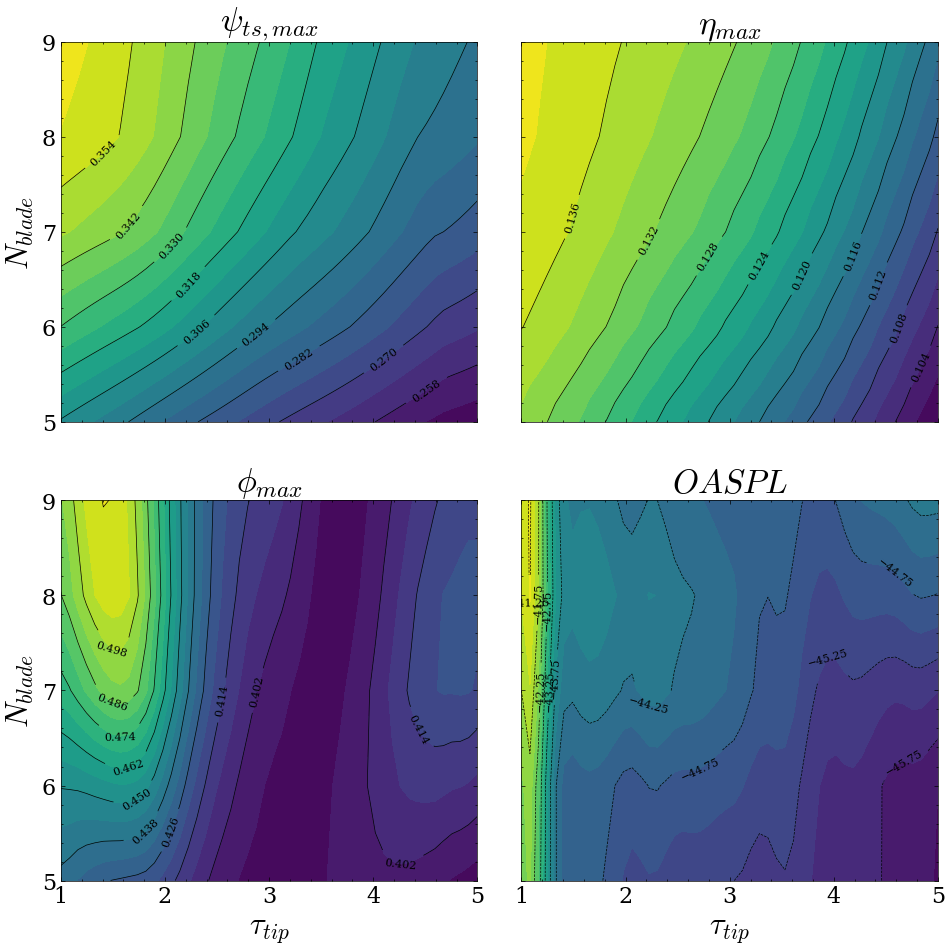

In [54]:
# tip clearance and blade count parameters
test_index_tip = 6
test_index_blade = 7
tips = np.linspace(PARAM_LO[6], PARAM_HI[6], 50)
blades = np.linspace(PARAM_LO[7], PARAM_HI[7], 5, endpoint=True)
# print(blades)

test_points_variable = np.array([[tip, blade] for tip in tips for blade in blades])
test_points_fixed_less = PARAM_DEFAULTS[:6]
test_points_fixed_more = PARAM_DEFAULTS[8:]
# print(test_points_fixed_less, test_points)
test_params = np.array([np.concatenate([test_points_fixed_less, test_point, test_points_fixed_more]) for test_point in test_points_variable])

x = test_points_variable[:, 0]  # x coordinates (phi values)
y = test_points_variable[:, 1]  # y coordinates  
idx = np.lexsort((x,y))
x, y, test_params = x[idx], y[idx], test_params[idx]

contour_plot_2x2(x, y, test_params, xlabel=r'$\tau_{tip}$', ylabel=r'$N_{blade}$', x_filename='tip_clearance', y_filename='blade_count')

In [58]:
def get_smoothed_curves_from_files(data_filepath, audio_filepath):
    
    curve_df = pd.read_csv(data_filepath)
    curve_df = curve_df[curve_df["dp_venturi_mean"] >= 0].copy()
    # print(curve_df)
    # psi
    end_phi   = float(curve_df["flow_coefficient_mean"].max())
    mean_psi, _, _ = load_with_gp_smooth(
                curve_df["flow_coefficient_mean"],
                curve_df["pressure_rise_coefficient_mean"],
                PHI_COMMON,
            )
    mean_psi = mean_psi[PHI_COMMON < end_phi]
    
    # eta
    mean_eta, _, _ = load_with_gp_smooth(
                curve_df["flow_coefficient_mean"],
                curve_df["efficiency_mean"],
                PHI_COMMON,
            )
    mean_eta = mean_eta[PHI_COMMON < end_phi]
    phi_common_masked = PHI_COMMON[PHI_COMMON < end_phi]
    
    # mean_psi = 0
    # mean_eta = 0
    # phi_common_masked = 0
    # noise
    
    audio_data, sample_rate = librosa.load(audio_filepath, sr=None)
    nperseg = len(audio_data)//8
    noverlap = nperseg//2  
    
    ## Plot ##
    frequencies, power = welch(
        audio_data,
        fs=sample_rate,
        window='blackman',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling = 'spectrum'
        )

    amplitude = np.sqrt(power)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)  
    
    amplitude_db = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
    # amplitude_db = np.array(pd.DataFrame(amplitude_db).rolling(window=9, center=True, min_periods=1).mean()).flatten()
    octave_freqs, a_weighted_octave_bands = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db)
    
    return phi_common_masked, mean_psi, mean_eta, octave_freqs, a_weighted_octave_bands
def get_nrmse_and_stats_inverse_pred(curve_pred, curve_real):
    X = curve_real
    X_reconstructed = curve_pred
    min = np.min(X)
    max = np.max(X)
    max_min = max - min
    
    rmse = np.sqrt(mean_squared_error(X, X_reconstructed))/max_min *100
    
    return rmse

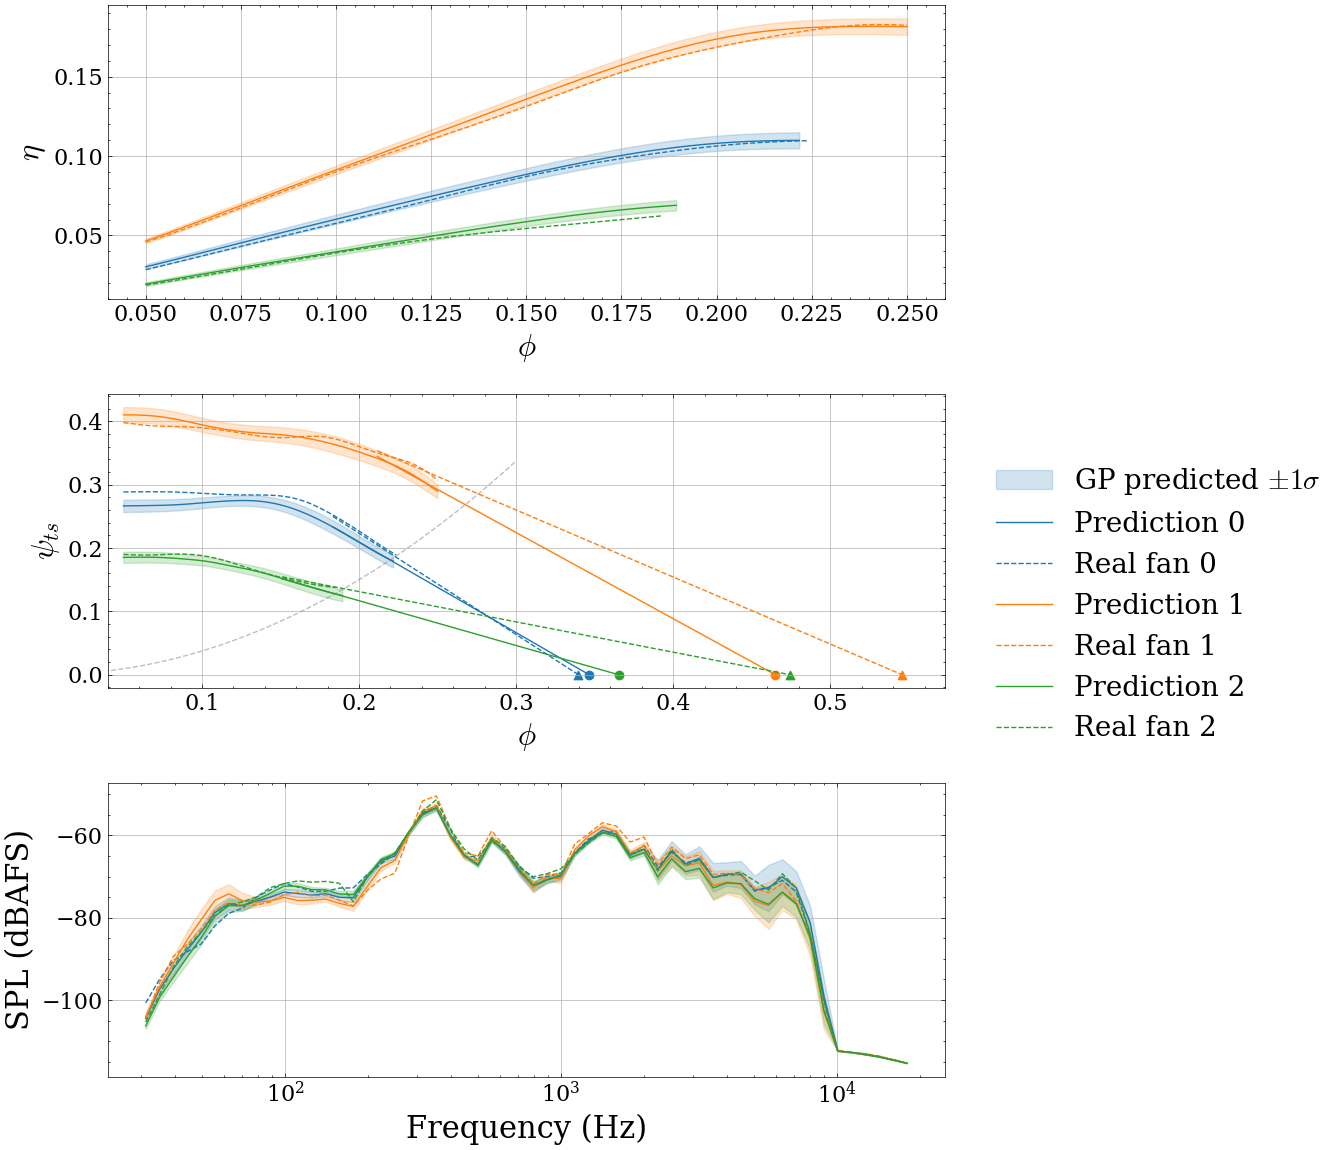

In [69]:
results = pd.read_csv(r'..\optimisation_results_2.csv')

centre_freqs = CENTRE_FREQS
pca_pressure   = joblib.load("../GPS_PKL/pca_pressure.pkl")
pca_efficiency = joblib.load("../GPS_PKL/pca_efficiency.pkl")
pca_noise      = joblib.load("../GPS_PKL/pca_noise.pkl")
gp_pressure   = joblib.load("../GPS_PKL/gp_pressure.pkl")
gp_efficiency = joblib.load("../GPS_PKL/gp_efficiency.pkl")
gp_noise      = joblib.load("../GPS_PKL/gp_noise.pkl")


n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=False)

files = os.listdir('../data/inverse_design_2/')
audio_files = os.listdir('../audio/inverse_design_2/')

pred_phi_maxs = []
pred_psi_maxs = []
pred_eta_maxs = []
pred_oaspls = []

real_psi_maxs = []
real_phi_maxs = []
real_eta_maxs = []
real_oaspls = []

nrmses_psi = []
nrmses_eta = []
nrmses_noise = []

for i, res in results.iterrows():
    # if i == 0:
    #     continue
    
    # if i >= 2 and i<=4:
    #     continue
    
    # if i==5:
    #     i=2
    # elif i==6:
    #     i=3
        
    # Load data
    file_name = files[i]
    filepath = f'../data/inverse_design_2/{file_name}'
    audio_file_name = audio_files[i]
    audio_filepath = f'../audio/inverse_design_2/{audio_file_name}'
    
    # print(filepath, audio_filepath)
    
    phi_common_masked, mean_psi, mean_eta, octave_freqs, a_weighted_octave_bands = get_smoothed_curves_from_files(filepath, audio_filepath)    
    if i==0:
        a_weighted_octave_bands = a_weighted_octave_bands# + difference_db
    
    real_psi_maxs.append(np.max(mean_psi))
    real_phi_maxs.append(axes_crossing(phi_common_masked, mean_psi)[1])
    real_eta_maxs.append(np.max(mean_eta))
    real_oaspls.append(calculate_oaspl(a_weighted_octave_bands))
    
    
    params = res.iloc[:8].to_numpy()

    # Predict curves with design params
    p_curve = pca_pressure.reconstruct(gp_pressure.predict(params)[0])
    e_curve = pca_efficiency.reconstruct(gp_efficiency.predict(params)[0])
    n_curve = pca_noise.reconstruct(gp_noise.predict(params)[0])
    
    
    
    m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = gp_pressure.predict(params)
    m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = gp_efficiency.predict(params)
    m_noise, s_noise = gp_noise.predict(params)
    
    phi_end_m = gp_pressure.predict(params)[4]
    mask = PHI_COMMON < phi_end_m
    
    p_curve = p_curve[mask]
    e_curve = e_curve[mask]
    PHI_PLOT = PHI_COMMON[mask]
    
    pred_phi_maxs.append(axes_crossing(PHI_COMMON, p_curve)[1])
    pred_psi_maxs.append(np.max(p_curve))
    pred_eta_maxs.append(np.max(e_curve))
    pred_oaspls.append(calculate_oaspl(n_curve))
    
    # NRMSEs
    min_val_psi = np.min([len(p_curve), len(mean_psi)])
    min_val_eta = np.min([len(e_curve), len(mean_eta)])

    rmse_psi = get_nrmse_and_stats_inverse_pred(p_curve[:min_val_psi], mean_psi[:min_val_psi])
    rmse_eta = get_nrmse_and_stats_inverse_pred(e_curve[:min_val_eta], mean_eta[:min_val_eta])
    rmse_noise = get_nrmse_and_stats_inverse_pred(n_curve, a_weighted_octave_bands)

    nrmses_psi.append(rmse_psi)
    nrmses_eta.append(rmse_eta)
    nrmses_noise.append(rmse_noise)

    var       = sum((pca_efficiency.modes[k] * s_eta[k]) ** 2 for k in range(pca_efficiency.n_modes))
    std       = np.sqrt(var)[mask]

    
    if i == 0:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0, label=f'GP predicted $\pm1\sigma$')
    else:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    ax[0].plot(PHI_PLOT, e_curve, color=colours[i], label=f'Prediction {i}')
    ax[0].plot(phi_common_masked, mean_eta, color=colours[i], linestyle='--', label=f'Real fan {i}')

    # PSI
    var       = sum((pca_pressure.modes[k] * s_psi[k]) ** 2 for k in range(pca_pressure.n_modes))
    std       = np.sqrt(var)[mask]

    n_points = 20    
    m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], p_curve[-n_points:])
    x_crossing = -c/m
    x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    ax[1].plot(x,m*x+c,color=colours[i])
    ax[1].scatter(x_crossing,0,marker='o',color=colours[i])
    # ax[1].scatter(0,np.max(p_curve),marker='o',color=colours[i])
    # ax[1].scatter(PHI_PLOT[np.argmax(p_curve)],np.max(p_curve),marker='o',color=colours[i])
    # target_x = input_params["phi_target"].iloc[i]
    # target_y = input_params["psi_target"].iloc[i]
    # ax.scatter(target_x,0,color=colours[i],edgecolors='red')
    # ax.axhline(target_y,linestyle='--',color=colours[i])
    

    ax[1].plot(PHI_PLOT, p_curve, color=colours[i])
    ax[1].plot(phi_common_masked, mean_psi, color=colours[i], linestyle='--')
    ax[1].fill_between(PHI_PLOT, pca_pressure.reconstruct(m_psi)[mask]-std, pca_pressure.reconstruct(m_psi)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], mean_psi[-n_points:])
    x_crossing = -c/m
    x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    ax[1].plot(x,m*x+c,color=colours[i],linestyle='--')
    ax[1].scatter(x_crossing,0,marker='^',color=colours[i])
    # ax[1].scatter(0,np.max(mean_psi),marker='^',color=colours[i])
    # ax[1].axhline(np.max(mean_psi),xmax=0.05,color=colours[i])
    
    # peak2 = np.max(mean_psi)
    # peak1 = np.max(p_curve)
    # ax[1].annotate('', xy=(ax[1].get_xlim()[0], peak2),
    #             xytext=(ax[1].get_xlim()[0], peak1),
    #         arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2,
    #                         shrinkA=0, shrinkB=0))
    # ax[1].text(ax[1].get_xlim()[0] - 0.2, (peak1 + peak2) / 2, f'Δ{peak2-peak1:.2f}',
    #     ha='right', va='center', fontsize=9)
    
    
    
    # Noise
    var       = sum((pca_noise.modes[k] * s_noise[k]) ** 2 for k in range(pca_noise.n_modes))
    std       = np.sqrt(var)

    ax[2].semilogx(centre_freqs, n_curve, color=colours[i])
    ax[2].semilogx(octave_freqs, a_weighted_octave_bands, color=colours[i], linestyle='--')
    ax[2].fill_between(centre_freqs, pca_noise.reconstruct(m_noise)-std, pca_noise.reconstruct(m_noise)+std, color=colours[i], alpha=0.2, zorder=0)
    
    
ax[0].grid()
ax[0].set_xlabel(r'$\phi$')
ax[0].set_ylabel(r'$\eta$')

ax[1].grid()
ax[1].set_xlabel(r'$\phi$')
ax[1].set_ylabel(r'$\psi_{ts}$')
x = np.linspace(0,0.3,50)
ax[1].plot(x,3.75*(x**2),color='grey',linestyle='--', alpha=0.5)
ax[1].set_xlim(0.04)

ax[2].grid()
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('SPL (dBAFS)')


extra_elements = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=colours[0], markeredgecolor='none',
           markersize=8, label=r'Predicted $\phi_{max}$'),
    Line2D([0], [0], marker='^', color='none',
           markerfacecolor=colours[0], markeredgecolor='none',
           markersize=8, label=r'Real $\phi_{max}$'),
]
extra_elements = []

existing_handles, existing_labels = ax[0].get_legend_handles_labels()


fig.legend(handles=existing_handles +extra_elements, bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\final_presentation_diagrams\predicted_fan_curves_with_real.svg', bbox_inches='tight')
plt.show()